# Projeto de BI: Análise Estatística e Geográfica de RH
**Objetivo:** Analisar a distribuição salarial e o mapeamento geopolítico dos colaboradores utilizando os dados extraídos do esquema `HR`.

## Preparação do Ambiente e Carga de Dados
*Importação das bibliotecas essenciais e leitura dos dados estruturados extraídos via SQL.*

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

*CARREGAMENTO DE DADOS*

In [94]:
df_query01 = pd.read_csv('query_01.csv')
df_query02 = pd.read_csv('query_02.csv')

*LEITURA DOS DADOS*

In [95]:
df_query01.head(10)

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE,MIN_SALARY,MAX_SALARY
0,100,Steven,King,24000,Executive,President,20080,40000
1,101,Neena,Yang,17000,Executive,Administration Vice President,15000,30000
2,102,Lex,Garcia,17000,Executive,Administration Vice President,15000,30000
3,200,Jennifer,Whalen,4400,Administration,Administration Assistant,3000,6000
4,108,Nancy,Gruenberg,12008,Finance,Finance Manager,8200,16000
5,109,Daniel,Faviet,9000,Finance,Accountant,4200,9000
6,110,John,Chen,8200,Finance,Accountant,4200,9000
7,111,Ismael,Sciarra,7700,Finance,Accountant,4200,9000
8,112,Jose Manuel,Urman,7800,Finance,Accountant,4200,9000
9,113,Luis,Popp,6900,Finance,Accountant,4200,9000


In [96]:
df_query02.head(10)

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,CITY,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME
0,100,Steven,King,24000,Executive,Seattle,Washington,United States of America,Americas
1,101,Neena,Yang,17000,Executive,Seattle,Washington,United States of America,Americas
2,102,Lex,Garcia,17000,Executive,Seattle,Washington,United States of America,Americas
3,103,Alexander,James,9000,IT,Southlake,Texas,United States of America,Americas
4,104,Bruce,Miller,6000,IT,Southlake,Texas,United States of America,Americas
5,105,David,Williams,4800,IT,Southlake,Texas,United States of America,Americas
6,106,Valli,Jackson,4800,IT,Southlake,Texas,United States of America,Americas
7,107,Diana,Nguyen,4200,IT,Southlake,Texas,United States of America,Americas
8,108,Nancy,Gruenberg,12008,Finance,Seattle,Washington,United States of America,Americas
9,109,Daniel,Faviet,9000,Finance,Seattle,Washington,United States of America,Americas


## Diagnóstico Estrutural e Auditoria de Qualidade
*Validação da volumetria, integridade dos tipos de dados e varredura de registros nulos ou duplicados nas bases de dados.*

*TAMANHO DA BASE*

In [97]:
## Tamanho da base de dados Query 01
df_query01.shape

(106, 8)

In [98]:
## Tamanho da base de dados Query 02
df_query02.shape

(106, 9)

*TIPOS DE DADOS*

In [99]:
## Primeiras linhas da base de dados Query 01
df_query01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EMPLOYEE_ID      106 non-null    int64 
 1   FIRST_NAME       106 non-null    object
 2   LAST_NAME        106 non-null    object
 3   SALARY           106 non-null    int64 
 4   DEPARTMENT_NAME  106 non-null    object
 5   JOB_TITLE        106 non-null    object
 6   MIN_SALARY       106 non-null    int64 
 7   MAX_SALARY       106 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 6.8+ KB


In [100]:
## Primeiras linhas da base de dados Query 02
df_query02.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EMPLOYEE_ID      106 non-null    int64 
 1   FIRST_NAME       106 non-null    object
 2   LAST_NAME        106 non-null    object
 3   SALARY           106 non-null    int64 
 4   DEPARTMENT_NAME  106 non-null    object
 5   CITY             106 non-null    object
 6   STATE_PROVINCE   105 non-null    object
 7   COUNTRY_NAME     106 non-null    object
 8   REGION_NAME      106 non-null    object
dtypes: int64(2), object(7)
memory usage: 7.6+ KB


*VERIFICA A QUALIDADE DOS DADOS*

In [101]:
#### QUERY 1

## Nulos por coluna
print(df_query01.isnull().sum())

## Dados duplicados
print(df_query01.duplicated().sum())

EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
SALARY             0
DEPARTMENT_NAME    0
JOB_TITLE          0
MIN_SALARY         0
MAX_SALARY         0
dtype: int64
0


In [102]:
#### QUERY 2

## Nulos por coluna
print(df_query02.isnull().sum())

## Dados duplicados
print(df_query02.duplicated().sum())

EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
SALARY             0
DEPARTMENT_NAME    0
CITY               0
STATE_PROVINCE     1
COUNTRY_NAME       0
REGION_NAME        0
dtype: int64
0


## Análise Descritiva dos Dados
*Cálculo das métricas de tendência central, limites salariais e distribuição geográfica.*

In [103]:
#### QUERY 1

## Estatísticas descritivas dos salários (Média, Mediana nos 50%, Mínimo e Máximo)
print(df_query01['SALARY'].describe())

## Cálculo do IQR 
q1 = df_query01['SALARY'].quantile(0.25)
q3 = df_query01['SALARY'].quantile(0.75)
iqr = q3 - q1
print(f"\nIQR dos Salários: {iqr}")

count      106.000000
mean      6456.754717
std       3927.798234
min       2100.000000
25%       3100.000000
50%       6150.000000
75%       8950.000000
max      24000.000000
Name: SALARY, dtype: float64

IQR dos Salários: 5850.0


In [104]:
#### QUERY 1

## Média salarial por departamento
df_query01.groupby('DEPARTMENT_NAME')['SALARY'].mean().round(2).sort_values(ascending=False)

DEPARTMENT_NAME
Executive           19333.33
Accounting          10154.00
Public Relations    10000.00
Marketing            9500.00
Sales                8955.88
Finance              8601.33
Human Resources      6500.00
IT                   5760.00
Administration       4400.00
Purchasing           4150.00
Shipping             3475.56
Name: SALARY, dtype: float64

In [105]:
#### QUERY 2

## Contagem de funcionários por país
print(df_query02['COUNTRY_NAME'].value_counts())

## Investigar qual linha/funcionário possui o valor nulo
print("\n")
df_query02[df_query02['STATE_PROVINCE'].isnull()]

COUNTRY_NAME
United States of America                                68
United Kingdom of Great Britain and Northern Ireland    35
Canada                                                   2
Germany                                                  1
Name: count, dtype: int64




,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,CITY,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME
102,203,Susan,Jacobs,6500,Human Resources,London,NaN,United Kingdom of Great Britain and Northern I...,Europe


## Visualização de Dados
*Construção de gráficos para análise visual da distribuição salarial e identificação de anomalias.*

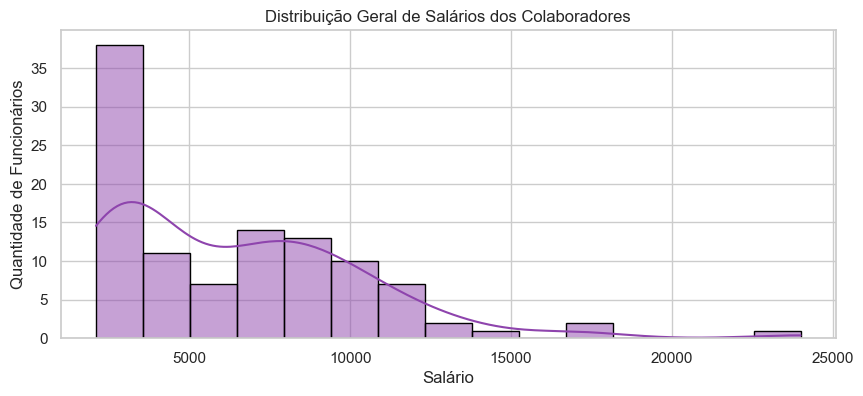

In [106]:
#### QUERY 1

## Distribuição Geral de Salários dos Colaboradores
plt.figure(figsize=(10, 4))
sns.histplot(df_query01['SALARY'], bins=15, kde=True, color='#8E44AD', edgecolor='black')
plt.title('Distribuição Geral de Salários dos Colaboradores')
plt.xlabel('Salário')
plt.ylabel('Quantidade de Funcionários')
plt.show()

C:\Users\Anaysa\AppData\Local\Temp\ipykernel_10900\2308165943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SALARY', y='DEPARTMENT_NAME', data=df_query01, palette='Purples')


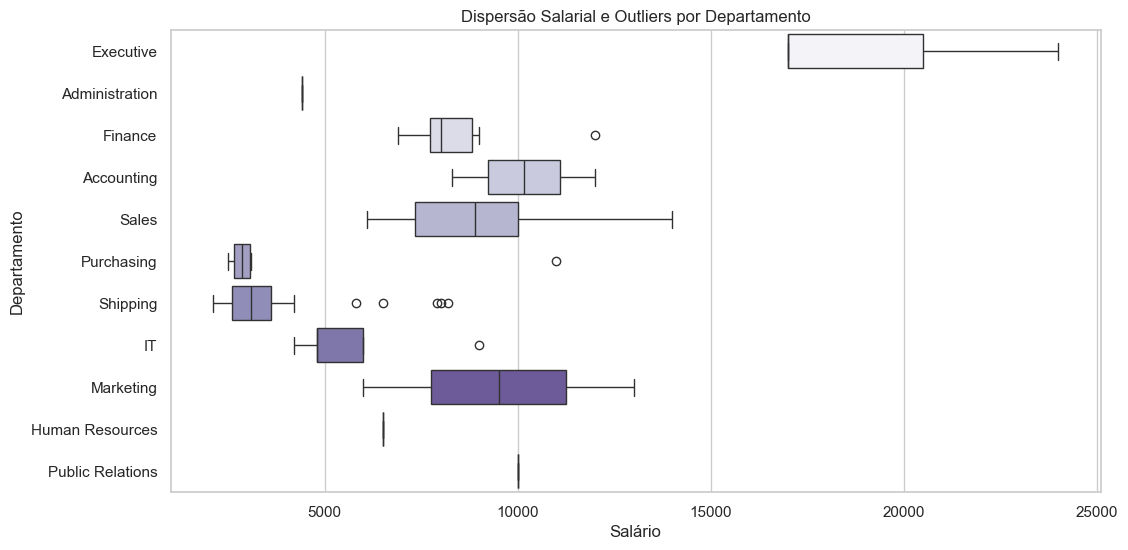

In [107]:
#### QUERY 1

## Salários por departamento
plt.figure(figsize=(12, 6))
sns.boxplot(x='SALARY', y='DEPARTMENT_NAME', data=df_query01, palette='Purples')
plt.title('Dispersão Salarial e Outliers por Departamento')
plt.xlabel('Salário')
plt.ylabel('Departamento')
plt.show()

C:\Users\Anaysa\AppData\Local\Temp\ipykernel_10900\3102173079.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cidades_dist.values, y=cidades_dist.index, palette='Purples_r', edgecolor='black')


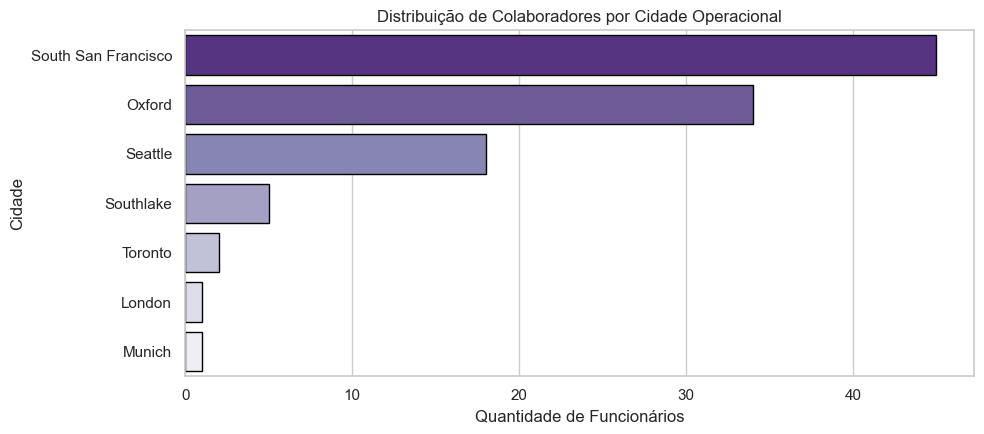

In [109]:
#### QUERY 2

# Contagem de funcionários por cidade 
cidades_dist = df_query02['CITY'].value_counts()

plt.figure(figsize=(10, 4.5))
sns.barplot(x=cidades_dist.values, y=cidades_dist.index, palette='Purples_r', edgecolor='black')
plt.title('Distribuição de Colaboradores por Cidade Operacional')
plt.xlabel('Quantidade de Funcionários')
plt.ylabel('Cidade')
plt.tight_layout()
plt.show()

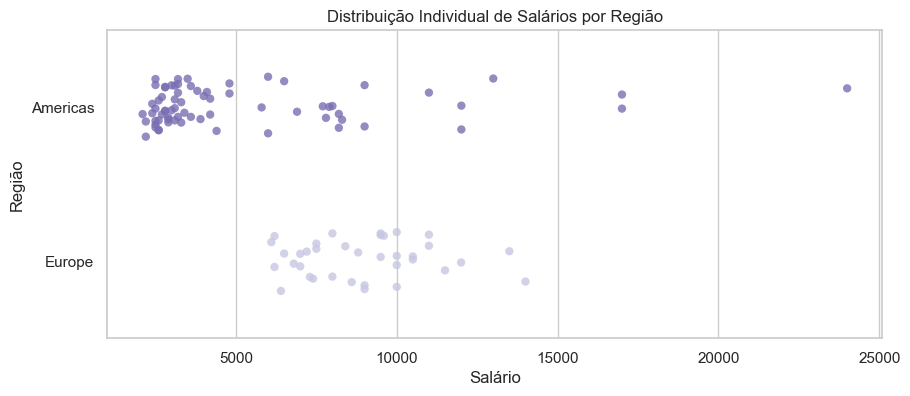

In [108]:
#### QUERY 2

## Gráfico de Dispersão Individual por Região
plt.figure(figsize=(10, 4))
sns.stripplot(x='SALARY', y='REGION_NAME', data=df_query02, palette='Purples_r', size=6, jitter=0.2, alpha=0.8, hue='REGION_NAME', legend=False)
plt.title('Distribuição Individual de Salários por Região')
plt.xlabel('Salário')
plt.ylabel('Região')
plt.show()